<a href="https://colab.research.google.com/github/SebastianD2/Lab_Biosenales/blob/main/Practica5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practica No. 5 - Analisis frecuencial

Juan Sebastian Daza Betancourt

Juan Jose Lopez Cuadros

---

In [ ]:
import scipy.io as sio
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

##4.1

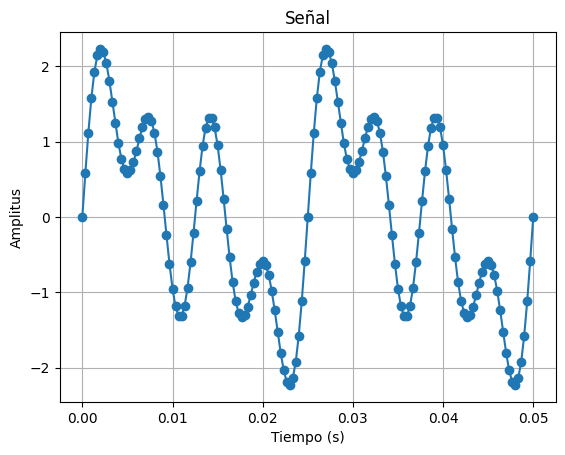

In [ ]:
# La fm minima segun el teorema de Nyquist es 2*fmax = 320 Hz, pero para la grafica usaremos una mayor para mas resolucion

Fm = 3000
Tm = 1/Fm

#Vector tiempo de 2 periodos de la señal con paso del periodo de muestreo
t = np.arange(0,2/40 + Tm,Tm)
x = np.sin(2*np.pi*t*40) + np.sin(2*np.pi*t*80) + np.sin(2*np.pi*t*160)


plt.plot(t,x,marker="o")
plt.grid()
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitus")
plt.title("Señal")
plt.show()

##4.2

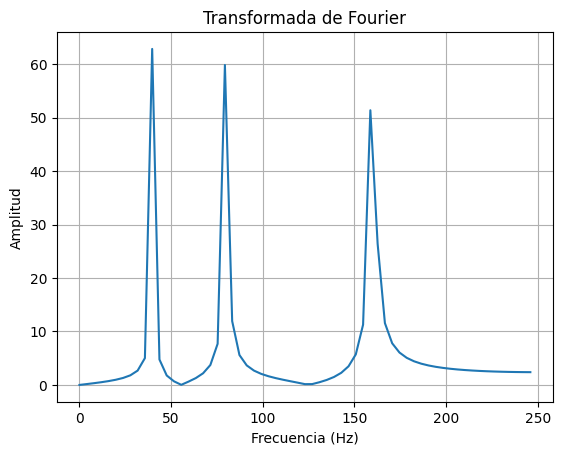

In [ ]:
#Calculamos la transformada de Fourier trabajando con 10 periodos de la señal y una frecuencia de muestro un poco mayor a la de Nyquist

#Con esta frecuencia podemos ver los 3 picos correspondientes
Fn = 500
Tn = 1/Fn
t2 = np.arange(0,10/40 + Tn,Tn)
x2 = np.sin(2*np.pi*t2*40) + np.sin(2*np.pi*t2*80) + np.sin(2*np.pi*t2*160)

#Calculamos la transformada con el eje x en Frecuencia (Hz) y la mitad original, no los alias.
X2 = np.fft.fft(x2)
N = len(X2)
Nm = int(np.ceil(N/2))
Fm = np.arange(0,Nm)*Fn/N
X2m = X2[0:Nm]

plt.plot(Fm,abs(X2m))
plt.title("Transformada de Fourier")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()


##4.3

/tmp/ipykernel_46754/1658742800.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


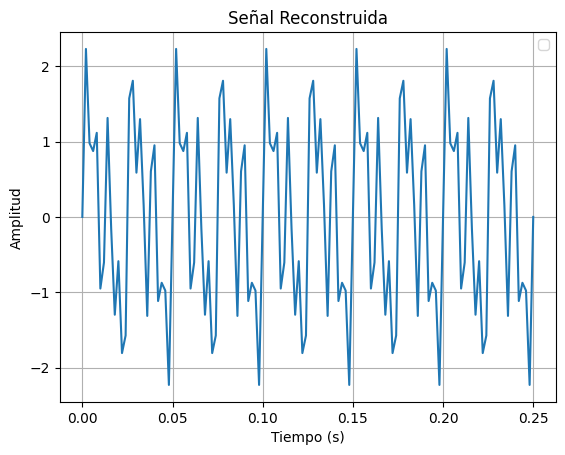

In [ ]:
#La transformada inversa se debe aplicar sobre el espectro completo
x_reconstruida = np.fft.ifft(X2)

plt.plot(t2, x_reconstruida)
plt.grid()
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal Reconstruida")
plt.legend()
plt.show()


##4.4


Rta: Sí, estas líneas aplican un filtro, específicamente un filtro de paso de banda ideal.
- Al crear un vector de ceros (F2) y copiar solo un rango específico de frecuencias (índices 9 a 13) de la FFT original, se están eliminando todas las demás componentes frecuenciales. La transformada inversa (ifft) reconstruye la señal solo con esas frecuencias permitidas.

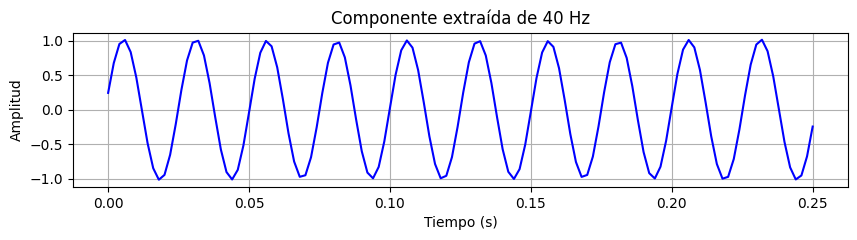

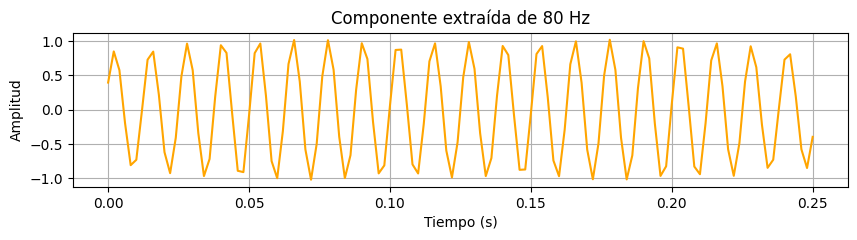

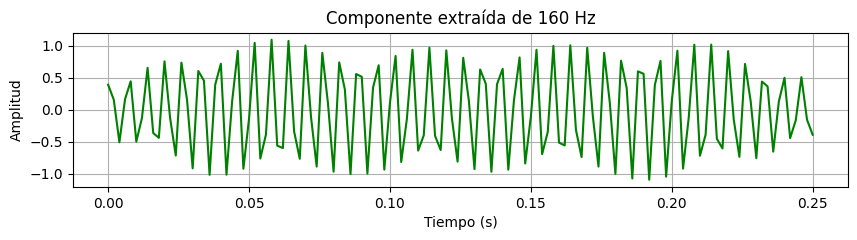

In [ ]:
# Extracción de cada componente (40, 80 y 160 Hz):
frecuencias_objetivo = [40, 80, 160]
colores = ['blue', 'orange', 'green']

for i, f_target in enumerate(frecuencias_objetivo):
    # Crear espectro vacío
    F_comp = np.zeros(len(X2), dtype=complex)

    # Calcular el índice correspondiente a la frecuencia (considerando 10 periodos de 40Hz)
    # El índice k se relaciona con F por: k = (F * N) / Fn
    idx = int(round((f_target * len(x2)) / Fn))
    margen = 2 # Pequeño margen para capturar el pico

    # Extraer componente (y su simétrico para la parte real)
    F_comp[idx-margen : idx+margen+1] = X2[idx-margen : idx+margen+1]
    F_comp[-idx-margen : -idx+margen+1] = X2[-idx-margen : -idx+margen+1]

    # Reconstrucción
    x_rec = np.fft.ifft(F_comp)

    plt.figure(figsize=(10, 2))
    plt.plot(t2, np.real(x_rec), color=colores[i])
    plt.title(f"Componente extraída de {f_target} Hz")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()

##4.5

dict_keys(['__header__', '__version__', '__globals__', 'ECG'])


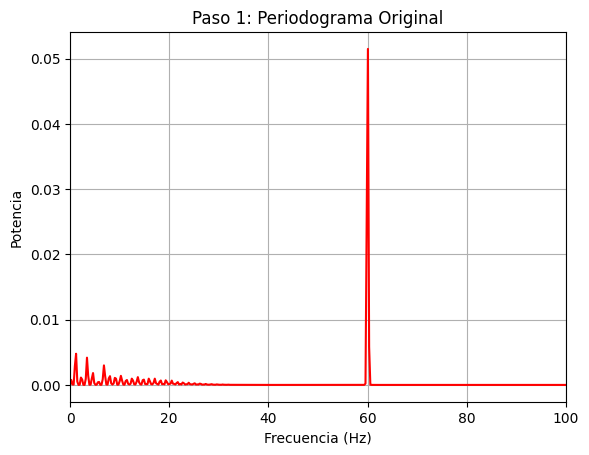

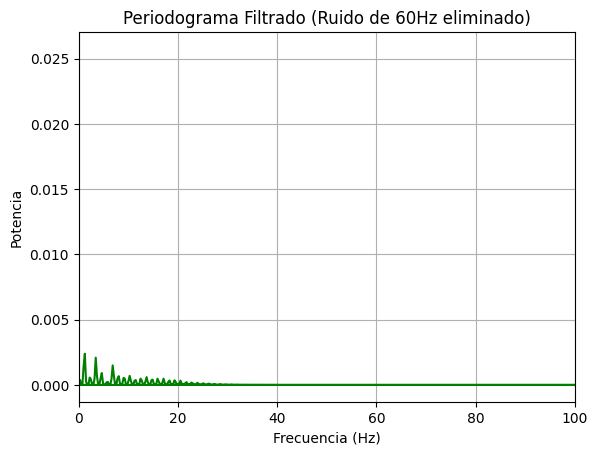

In [ ]:
mat_data = sio.loadmat('senecg.mat')
print(mat_data.keys())
x = mat_data['ECG'].flatten()

fs = 250 # Frecuencia de muestreo (Hz)
N = len(x)
t = np.arange(0, N) / fs

#PERIODOGRAMA DE WELCH
# Ventana Hanning: Suaviza los bordes para reducir la fuga espectral.
# nperseg = 1024: A 250 Hz, esto equivale a  casi 4 segundos.
#Suficientemente ancho para capturar varios latidos y tener buena resolución.
# noverlap = 512: Solapamiento del 50% recupera la información atenuada por los bordes de la ventana.
nperseg = 1024
noverlap = int(nperseg / 2)

f_orig, Pxx_orig = welch(x, fs, window='hann', nperseg=nperseg, noverlap=noverlap)

plt.plot(f_orig, Pxx_orig, color='red')
plt.title('Paso 1: Periodograma Original')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Potencia')
plt.xlim(0, 100)
plt.grid(True)
plt.show()

# En la grafica del periodograma original podemos ver un pico de ruido a los 60 Hz,
#el ruido correspondiente a la red electrica, ese será el que vamso a filtrar.


#FILTRADO

F1 = np.fft.fft(x)
f_ruido = 60

# Calculamos qué índice correspondiente a esos 60 Hz
indice_ruido = int((f_ruido * N) / fs)
margen = 3

# Borramos el ruido del espectro
F1[(indice_ruido - margen):(indice_ruido + margen)] = 0

# Calculamos la transformada inversa y volvemos a calcular welch
xr = np.fft.ifft(F1)
f_filt, Pxx_filt = welch(xr, fs, window='hann', nperseg=nperseg, noverlap=noverlap)

plt.plot(f_filt, Pxx_filt, color='green')
plt.title(f'Periodograma Filtrado (Ruido de {f_ruido}Hz eliminado)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Potencia')
plt.xlim(0, 100)
plt.grid(True)
plt.show()

#En la grafica de la señal filtrada es posible evidenciar que a 60 Hz ya no hay un pico correspondiente al ruido.

## 4.6

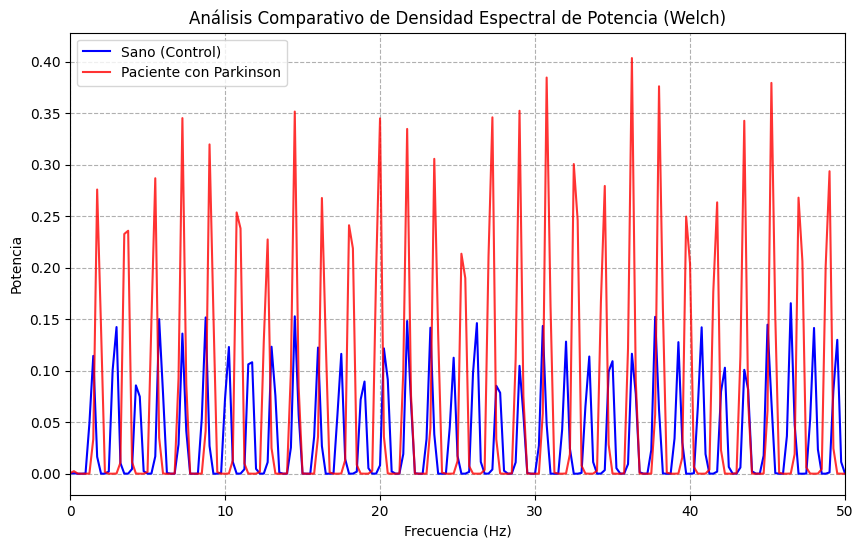

In [ ]:
# Carga de datos
data_control = sio.loadmat('C012_EP_reposo_CONTROL.mat')
data_parkinson = sio.loadmat('P004_EP_reposo_PARKISON.mat')

# Extraemos la señal
# Usamos el primer canal [0, :] para la comparación
sig_control = data_control['data'][0, :].flatten()
sig_parkinson = data_parkinson['data'][0, :].flatten()

fs = 250

# Configuración del Periodograma de Welch
# Justificación de parámetros:
# Ventana Hanning: Para reducir la fuga espectral en señales no estacionarias como el EEG.
# nperseg = 1000: A 250Hz, esto nos da una resolución de 0.25Hz, suficiente para identificar ritmos cerebrales alpha, beta y theta.
# noverlap = 50%: se suaviza el espectro sin perder excesiva información de los bordes.

nperseg = 1000
noverlap = nperseg // 2

f_con, Pxx_con = welch(sig_control, fs, window='hann', nperseg=nperseg, noverlap=noverlap)
f_pk, Pxx_pk = welch(sig_parkinson, fs, window='hann', nperseg=nperseg, noverlap=noverlap)

# 3. Graficación comparativa
plt.figure(figsize=(10, 6))
plt.plot(f_con, Pxx_con, label='Sano (Control)', color='blue')
plt.plot(f_pk, Pxx_pk, label='Paciente con Parkinson', color='red', alpha=0.8)

plt.title('Análisis Comparativo de Densidad Espectral de Potencia (Welch)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Potencia')
plt.xlim(0, 50)  # Limitamos a 50Hz para observar las bandas de interés clínico
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

###Conclusiones
- Se demostró que la FFT es una herramienta precisa para la identificación de ruido estacionario, como la interferencia de los 60 Hz de la red eléctrica. Al anular los coeficientes específicos en el espectro y aplicar la ifft, se logró limpiar la señal de ECG sin alterar significativamente los componentes morfológicos del complejo QRS, lo cual es es muy relevante en el diagnóstico clínico.
- A diferencia del periodograma simple, el método de Welch permitió obtener una estimación de la PSD más suave y con menor varianza. El uso de la ventana Hanning y el solapamiento del 50% resultó fundamental para reducir la fuga espectral, permitiendo una identificación clara de los ritmos cerebrales en las señales de EEG.
- Mediante el análisis frecuencial de las señales de EEG, se evidenciaron variaciones en la potencia de ciertas bandas como alpha y beta. Estas diferencias cuantitativas en el espectro de potencia nos confirman el uso del análisis de frecuencia como una herramienta de apoyo en la detección de biomarcadores para enfermedades neurodegenerativas, permitiendo observar el estado de salud del paciente.

###Bibliografia
- Proakis, J. G., & Manolakis, D. G. (2007). Digital Signal Processing: Principles, Algorithms, and Applications. Pearson Prentice Hall.

- Bronzino, J. D. (Ed.). (2000). The Biomedical Engineering Handbook. CRC Press.

- Oppenheim, A. V., & Schafer, R. W. (2010). Discrete-Time Signal Processing. Pearson.